In [ ]:
# !pip install pyarabic
# !pip install camel-tools
# !pip install openpyxl

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import nltk
import pyarabic.araby as araby

# nltk.download('punkt_tab')
# nltk.download('stopwords', quiet=True)
# nltk.download('wordnet', quiet=True)

from camel_tools.tokenizers.word import simple_word_tokenize
from camel_tools.disambig.mle import MLEDisambiguator
from camel_tools.morphology.database import MorphologyDB

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.isri import ISRIStemmer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

#Part 1 – Data Exploration

##Load Dataset

In [ ]:
data = pd.read_excel("Arabic Sentiment Analysis.xlsx")

##Display the first 5 rows

In [ ]:
data.head()

,review_description,rating
0,شركه زباله و سواقين بتبرشم و مفيش حتي رقم للشك...,-1
1,خدمة الدفع عن طريق الكي نت توقفت عندي اصبح فقط...,1
2,تطبيق غبي و جاري حذفه ، عاملين اكواد خصم و لما...,-1
3,فعلا تطبيق ممتاز بس لو فى امكانية يتيح لمستخدم...,1
4,سيء جدا ، اسعار رسوم التوصيل لا تمت للواقع ب ص...,-1


##Check dataset information

In [ ]:
print(data.shape)

(32036, 2)


In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32036 entries, 0 to 32035
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_description  32036 non-null  object
 1   rating              32036 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 500.7+ KB
None


In [ ]:
print(data.duplicated().sum())

651


In [ ]:
data.drop_duplicates()

,review_description,rating
0,شركه زباله و سواقين بتبرشم و مفيش حتي رقم للشك...,-1
1,خدمة الدفع عن طريق الكي نت توقفت عندي اصبح فقط...,1
2,تطبيق غبي و جاري حذفه ، عاملين اكواد خصم و لما...,-1
3,فعلا تطبيق ممتاز بس لو فى امكانية يتيح لمستخدم...,1
4,سيء جدا ، اسعار رسوم التوصيل لا تمت للواقع ب ص...,-1
...,...,...
32031,التطبيق اصبح سيء للغايه نقوم بطلب لا يتم وصول ...,-1
32032,y love you,1
32033,الباقه بتخلص وبشحن مرتين باقه اضافيه ١٠٠ جنيه,-1
32034,تطبيق فاشل وصلني الطلب ناقص ومش ينفع اعمل حاجة...,-1


##Check missing values

In [ ]:
data.isnull().sum()

,0
review_description,0
rating,0


##Display the number of samples in each class

In [ ]:
print(data["rating"].value_counts())

rating
 1    19189
-1    11340
 0     1507
Name: count, dtype: int64


##Visualize the Class Distribution using Count Plot

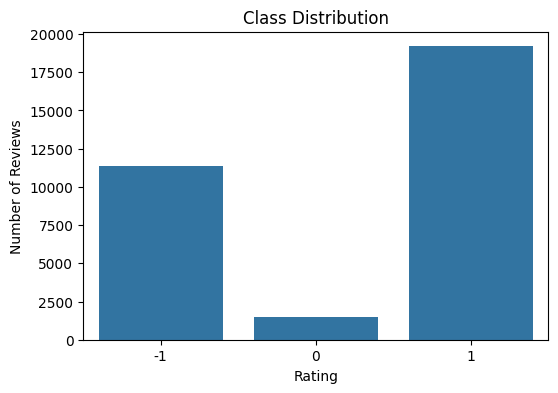

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x="rating",
    order=[-1, 0, 1]
)

plt.title("Class Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

#Part 2 – Arabic Text Preprocessing

In [ ]:
arabic_stopwords = set(stopwords.words("arabic"))
stemmer = ISRIStemmer()

def preprocessing(text):
    # remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove English letters
    text = re.sub(r"[A-Za-z]", "", text)

    # remove tashkeel & tatweel
    text = araby.strip_tashkeel(text)
    text = araby.strip_tatweel(text)

    # normalize
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ة", "ه", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # tokenize
    words = nltk.word_tokenize(text)

    # remove stop words
    words = [word for word in words if word not in arabic_stopwords]

    # stem using ISRIStemmer
    # words = [stemmer.stem(word) for word in words]

    # join words back into a sentence
    return " ".join(words)

In [ ]:
data['clean_text'] = data['review_description'].apply(preprocessing)

In [ ]:
data['clean_text'].head()

,clean_text
0,شركه زباله سواقين بتبرشم مفيش حتي رقم للشكاوي ...
1,خدمه الدفع طريق الكي نت توقفت عندي اصبح فقط ال...
2,تطبيق غبي جاري حذفه عاملين اكواد خصم نستخدمها ...
3,فعلا تطبيق ممتاز امكانيه يتيح لمستخدم التطبيق ...
4,سيء جدا اسعار رسوم التوصيل تمت للواقع صله


#Part 3 – Text Encoding

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data["clean_text"])

In [ ]:
vocab_size = len(tokenizer.word_index)
print("Vocabulary size:", vocab_size)

Vocabulary size: 35617


In [ ]:
sequences = tokenizer.texts_to_sequences(data["clean_text"])

In [ ]:
sentence_lengths = [len(seq) for seq in sequences]
lengths = pd.Series(sentence_lengths)
print(lengths.describe())

count    32036.000000
mean         7.606536
std         10.088847
min          0.000000
25%          2.000000
50%          4.000000
75%          9.000000
max        315.000000
dtype: float64


In [ ]:
print("90th percentile:", lengths.quantile(0.90))
print("95th percentile:", lengths.quantile(0.95))
print("99th percentile:", lengths.quantile(0.99))

90th percentile: 18.0
95th percentile: 25.0
99th percentile: 50.0


In [ ]:
max_length = 50
X = pad_sequences(sequences, maxlen=max_length, padding="post")
print(X)

[[   36    62   993 ...     0     0     0]
 [   11   263   183 ...     0     0     0]
 [    2  1025   789 ...     0     0     0]
 ...
 [ 1213  5951 35616 ...     0     0     0]
 [    2    35   499 ...     0     0     0]
 [   64   148   254 ...     0     0     0]]


In [ ]:
print("Shape of final input data:", X.shape)

Shape of final input data: (32036, 50)


#Part 4 – Data Splitting

In [ ]:
Y = data["rating"]

In [ ]:
print(Y.unique())
print(Y.value_counts())
print(Y.isna().sum())
print(Y.dtype)

[-1  1  0]
rating
 1    19189
-1    11340
 0     1507
Name: count, dtype: int64
0
int64


In [ ]:
Y = data["rating"].map({
    -1: 0,
     0: 1,
     1: 2
})

In [ ]:
print(Y.unique())

[0 2 1]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

#Part 5 – Build a GRU Model

In [ ]:
model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    )
)

model.add(GRU(64))
model.add(Dense(3, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#Part 6 – Model Training

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6905 - loss: 0.6936 - val_accuracy: 0.8291 - val_loss: 0.4731
Epoch 2/5
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8561 - loss: 0.4205 - val_accuracy: 0.8361 - val_loss: 0.4678
Epoch 3/5
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9007 - loss: 0.3051 - val_accuracy: 0.8244 - val_loss: 0.5242
Epoch 4/5
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9216 - loss: 0.2410 - val_accuracy: 0.7936 - val_loss: 0.6264
Epoch 5/5
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9389 - loss: 0.1889 - val_accuracy: 0.7952 - val_loss: 0.6573


##Accuracy Plot

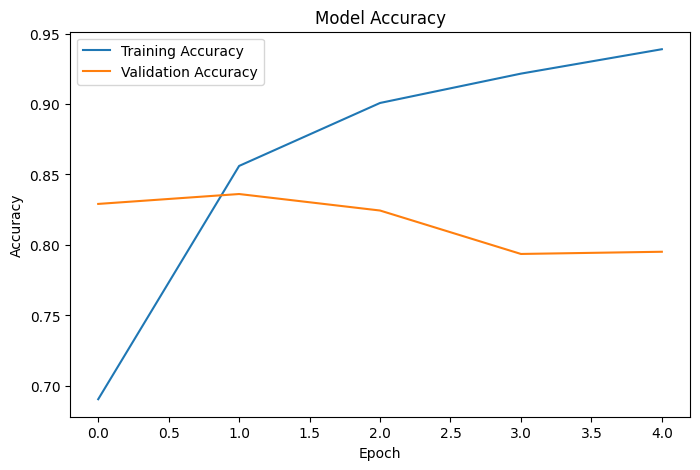

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

##Loss Plot

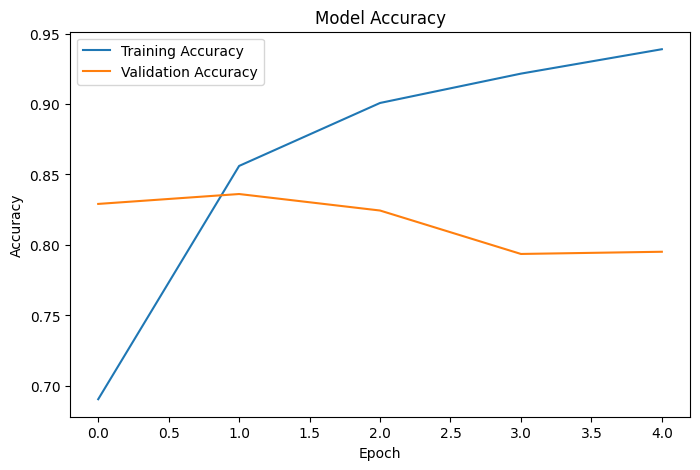

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

#Part 7 – Model Evaluation

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.783551812171936


In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[1690  207  371]
 [ 119   53  130]
 [ 358  202 3278]]


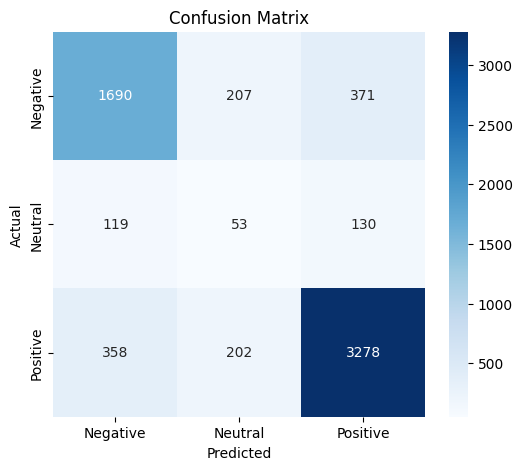

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Neutral", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.78      0.75      0.76      2268
     Neutral       0.11      0.18      0.14       302
    Positive       0.87      0.85      0.86      3838

    accuracy                           0.78      6408
   macro avg       0.59      0.59      0.59      6408
weighted avg       0.80      0.78      0.79      6408

